In [1]:
import pandas as pd
import numpy as np

## Feature Engineering

### Feature Transformation

Finding the distribution of data 

In [ ]:
numerical_cols

Index(['math_score', 'reading_score', 'writing_score'], dtype='object')

In [ ]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
# EXAMPLE OF FUNCTION TRANSFORMER:
from sklearn.preprocessing import FunctionTransformer
import numpy as np

# Define a custom function to calculate the square of the input data
def square_func(X):
    return np.square(X)

# Create a function transformer using the custom function
square_transformer = FunctionTransformer(func=square_func)

X = df.drop(columns= ['math_score'])
y = df['math_score']
df[['reading_score', 'writing_score']] = square_transformer.fit_transform(X[['reading_score', 'writing_score']])

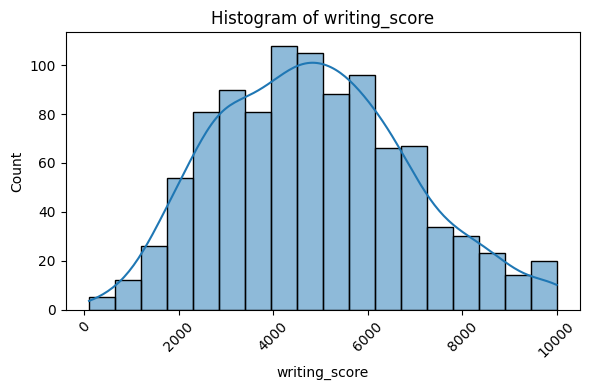

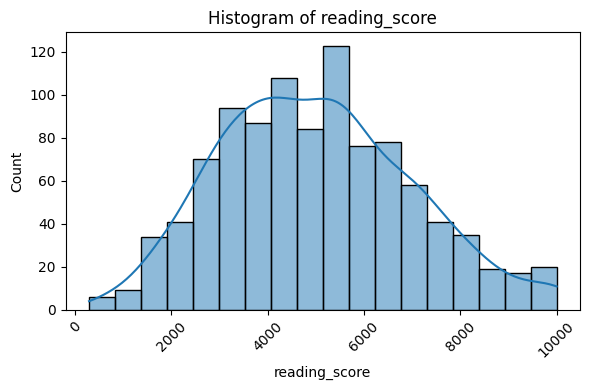

In [ ]:
for col in ['writing_score', 'reading_score']:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Histogram of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Handling outliers

In [ ]:
df_filtered = df.copy()

for col in numerical_cols:
    lower = df_filtered[col].quantile(0.025)
    upper = df_filtered[col].quantile(0.975)
    df_filtered = df_filtered[(df_filtered[col] >= lower) & (df_filtered[col] <= upper)]

df_filtered.shape

(880, 8)

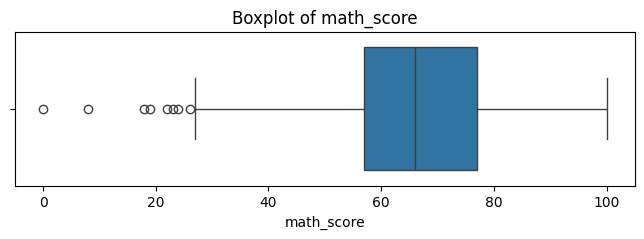

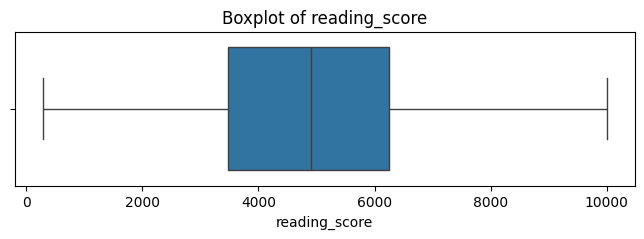

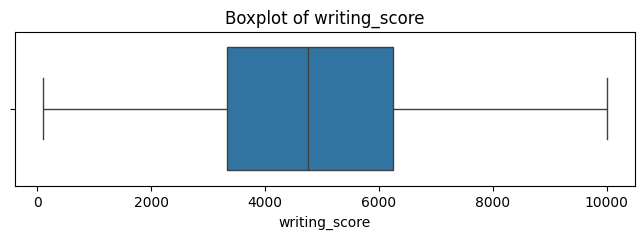

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include="number").columns

for col in numerical_cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()